# Cell 1: Imports and Configurations

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
import re
import os
from pydantic import BaseModel, Field
from dataclasses import dataclass

from dotenv import load_dotenv
load_dotenv()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@dataclass
class cfg:
  reward_weights = {"correctness": 0.6, "similarity": 0.2, "adherence": 0.2}


# Cell 2: Load Qwen

In [ ]:
judge_model_id = "Qwen/Qwen2.5-3B-Instruct"

judge_tokenizer = AutoTokenizer.from_pretrained(judge_model_id)
judge_tokenizer.pad_token = judge_tokenizer.eos_token

judge_model = AutoModelForCausalLM.from_pretrained(
    judge_model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

judge_model.eval()
for param in judge_model.parameters():
    param.requires_grad = False


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

# Cell 3: Helper Function

In [ ]:
class EvaluationScores(BaseModel):
    similarity_check: float = Field(description="Score between 0.0 and 1.0")
    correctness_check: float = Field(description="Score between 0.0 and 1.0")
    context_adherence: float = Field(description="Score between 0.0 and 1.0")


def local_qwen_judge(question, context, gold_answer, generated_answer, cfg):
    prompt = f"""You are an expert evaluator for RAG systems.
Analyze the following data points and return a JSON object.

**Input Data:**
- Question: "{question}"
- Context: "{context}"
- Gold Answer: "{gold_answer}"
- Generated Answer: "{generated_answer}"

**Task:**
Evaluate the 'Generated Answer' on these 3 metrics using a float scale from 0.0 to 1.0 (where 0.0 is completely wrong/absent, and 1.0 is perfect):
1. similarity_check: Score the semantic similarity between the Generated Answer and the Gold Answer.
2. correctness_check: Score how correctly the Generated Answer answers the Question.
3. context_adherence: Score how well the Generated Answer relies ONLY on data/information derived from the provided Context.

**Output Format:**
Return ONLY a JSON object with keys: "similarity_check", "correctness_check", "context_adherence".
"""

    messages = [
        {"role": "system", "content": "You are a strict JSON output machine. You only output valid JSON."},
        {"role": "user", "content": prompt}
    ]

    text = judge_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = judge_tokenizer(text, return_tensors="pt").to(judge_model.device)

    with torch.no_grad():
        outputs = judge_model.generate(
            **inputs,
            max_new_tokens=60,
            temperature=0.0,    # Greedy decoding for consistent grading
            do_sample=False,
            pad_token_id=judge_tokenizer.eos_token_id
        )

    response_text = judge_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

    # Robust JSON extraction
    try:
        json_match = re.search(r'\{.*?\}', response_text, re.DOTALL)
        if json_match:
            data = json.loads(json_match.group(0))
        else:
            data = json.loads(response_text)

        c_check = max(0.0, min(1.0, float(data.get('correctness_check', 0.0))))
        s_check = max(0.0, min(1.0, float(data.get('similarity_check', 0.0))))
        a_check = max(0.0, min(1.0, float(data.get('context_adherence', 0.0))))

    except Exception as e:
        print(f"JSON Parsing error: {e} | Raw Output: {response_text}")
        c_check, s_check, a_check = 0.0, 0.0, 0.0

    return c_check, s_check, a_check


# Cell 4: Using

In [ ]:
question = "What new offering did ZenSpace Yoga launch in early 2024 to differentiate from competitors?"
context_text = """Sarah Nguyen of ZenSpace Yoga announced in early 2024 that they launched virtual reality meditation classes. According to Nguyen, this immersive experience sets ZenSpace Yoga apart from competitors."""
gold_answer = "ZenSpace Yoga launched virtual reality meditation classes."
generated_answer = "launched virtual computer games classes."

In [ ]:
reward = local_qwen_judge(question, context_text, gold_answer, generated_answer, cfg)
print(reward)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


(0.0, 0.8, 0.0)


# Cell 5: using phase1 injector on test set

In [ ]:
import pandas as pd
from tqdm import tqdm

tqdm.pandas()

# File paths
input_csv = "./test_results_phase1_layer16_FULL-V3.csv"
output_csv = "./test_results_phase1_layer16_FULL-V3_scored.csv"

df = pd.read_csv(input_csv)

def get_scores(row):
    correctness, similarity, adherence = local_qwen_judge(
        question=row['question'],
        context=row['context'],
        gold_answer=row['gold_answer'],
        generated_answer=row['generated_answer'],
        cfg=cfg
    )
    return pd.Series([correctness, similarity, adherence])

# Use progress_apply instead of apply to see a progress bar
df[['correctness', 'similarity', 'adherence']] = df.progress_apply(get_scores, axis=1)

df.to_csv(output_csv, index=False)


100%|██████████| 1192/1192 [31:12<00:00,  1.57s/it]


# Cell 6: Plots

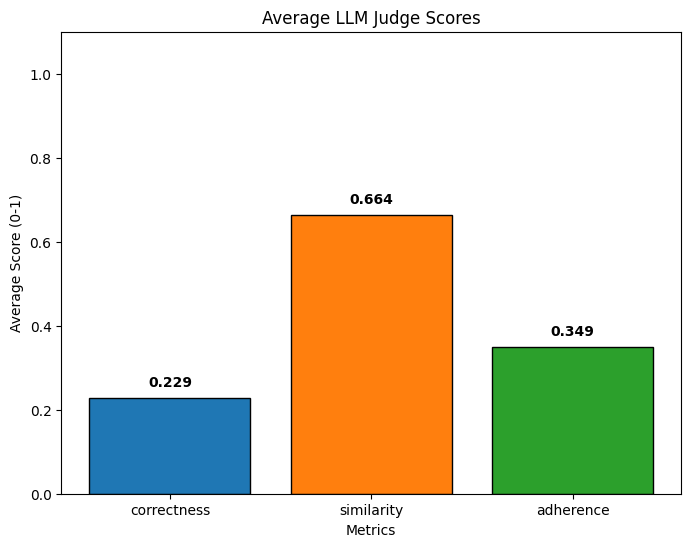

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the scored CSV
csv_path = "./test_results_phase1_layer16_FULL-V3_scored.csv"
df = pd.read_csv(csv_path)

# Calculate the mean for the 3 score columns
score_columns = ['correctness', 'similarity', 'adherence']
averages = df[score_columns].mean()

# Create the plot
plt.figure(figsize=(8, 6))
bars = plt.bar(averages.index, averages.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')

# Set y-axis limits since scores are between 0 and 1
plt.ylim(0, 1.1)  # slightly above 1 to leave room for the text labels

# Add titles and labels
plt.title('Average LLM Judge Scores')
plt.ylabel('Average Score (0-1)')
plt.xlabel('Metrics')

# Add the exact values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.show()

/tmp/ipykernel_8348/2581854780.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


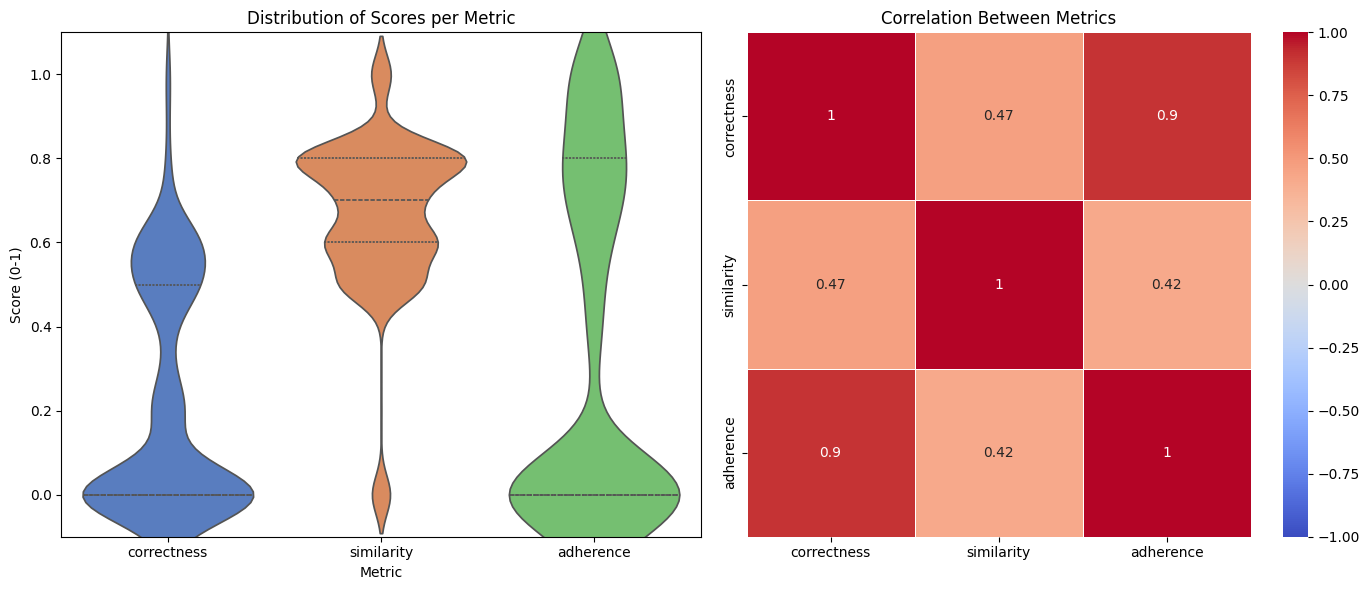

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the scored CSV
csv_path = "./test_results_phase1_layer16_FULL-V3_scored.csv"
df = pd.read_csv(csv_path)

score_columns = ['correctness', 'similarity', 'adherence']

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Violin Plot (Distribution of scores) ---
# We need to "melt" the dataframe to make it easy to plot with seaborn
df_melted = df[score_columns].melt(var_name='Metric', value_name='Score')

sns.violinplot(
    data=df_melted,
    x='Metric',
    y='Score',
    ax=axes[0],
    palette='muted',
    inner='quartile' # Shows the median and quartiles inside the violin
)
axes[0].set_title('Distribution of Scores per Metric')
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_ylabel('Score (0-1)')

# --- Plot 2: Correlation Heatmap ---
# Calculate the Pearson correlation matrix
corr_matrix = df[score_columns].corr()

sns.heatmap(
    corr_matrix,
    annot=True,          # Show the exact correlation numbers
    cmap='coolwarm',     # Blue for low/negative correlation, Red for high
    vmin=-1, vmax=1,     # Correlation ranges from -1 to 1
    ax=axes[1],
    square=True,
    linewidths=.5
)
axes[1].set_title('Correlation Between Metrics')

plt.tight_layout()
plt.show()

# Cell 7: Using Phase2 on test set

In [ ]:
import pandas as pd
from tqdm import tqdm

tqdm.pandas()

# File paths
input_csv = "./test_results_phase2_layer16_FULL-V3.csv"
output_csv = "./test_results_phase2_layer16_FULL-V3_scored.csv"

df = pd.read_csv(input_csv)

def get_scores(row):
    correctness, similarity, adherence = local_qwen_judge(
        question=row['question'],
        context=row['context'],
        gold_answer=row['gold_answer'],
        generated_answer=row['generated_answer'],
        cfg=cfg
    )
    return pd.Series([correctness, similarity, adherence])

# Use progress_apply instead of apply to see a progress bar
df[['correctness', 'similarity', 'adherence']] = df.progress_apply(get_scores, axis=1)

df.to_csv(output_csv, index=False)


  0%|          | 0/1192 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

100%|██████████| 1192/1192 [31:12<00:00,  1.57s/it]


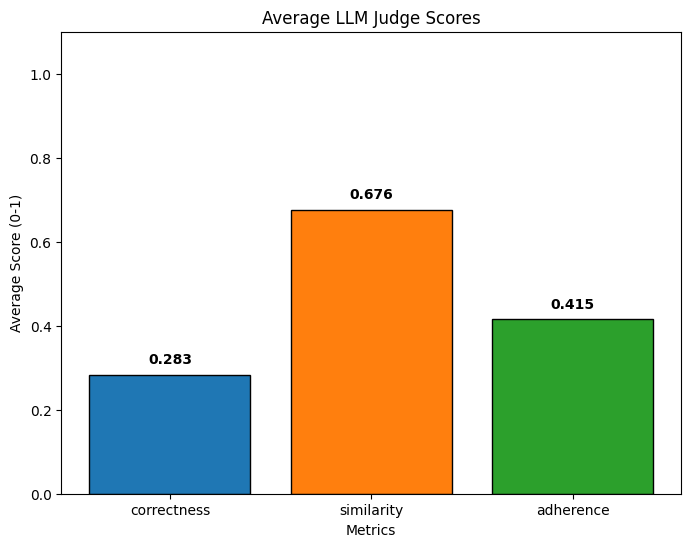

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the scored CSV
csv_path = "./test_results_phase2_layer16_FULL-V3_scored.csv"
df = pd.read_csv(csv_path)

# Calculate the mean for the 3 score columns
score_columns = ['correctness', 'similarity', 'adherence']
averages = df[score_columns].mean()

# Create the plot
plt.figure(figsize=(8, 6))
bars = plt.bar(averages.index, averages.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')

# Set y-axis limits since scores are between 0 and 1
plt.ylim(0, 1.1)  # slightly above 1 to leave room for the text labels

# Add titles and labels
plt.title('Average LLM Judge Scores')
plt.ylabel('Average Score (0-1)')
plt.xlabel('Metrics')

# Add the exact values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.show()

/tmp/ipykernel_832/3065090098.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


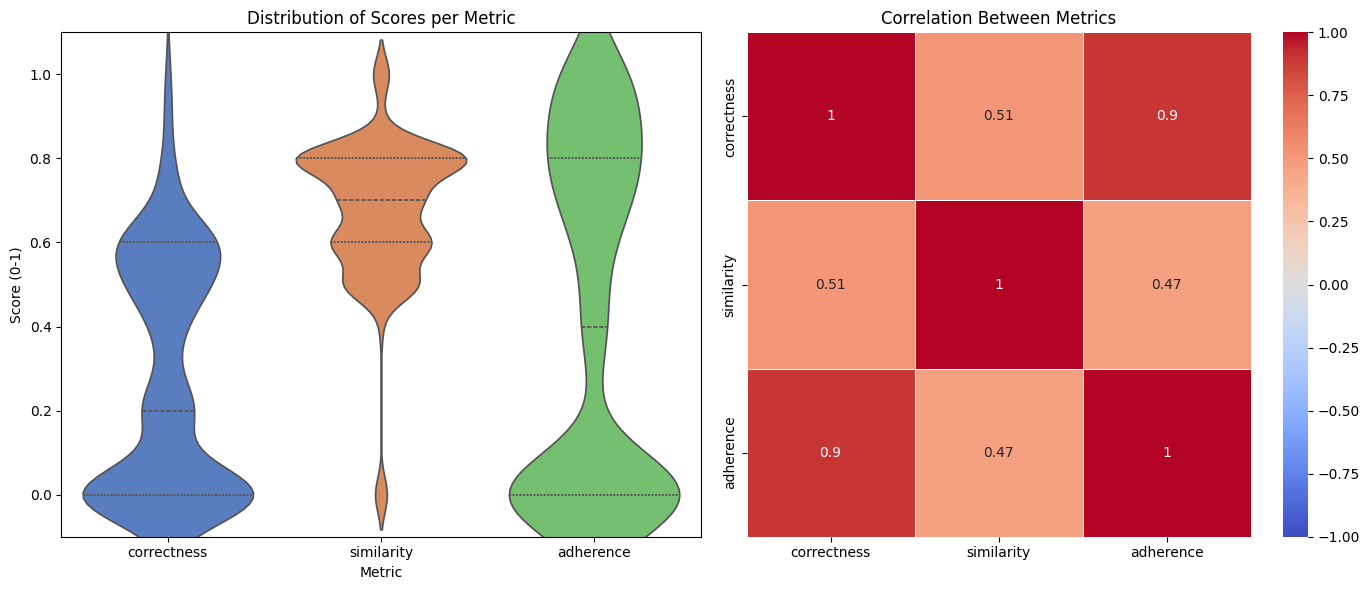

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the scored CSV
csv_path = "./test_results_phase2_layer16_FULL-V3_scored.csv"
df = pd.read_csv(csv_path)

score_columns = ['correctness', 'similarity', 'adherence']

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Violin Plot (Distribution of scores) ---
# We need to "melt" the dataframe to make it easy to plot with seaborn
df_melted = df[score_columns].melt(var_name='Metric', value_name='Score')

sns.violinplot(
    data=df_melted,
    x='Metric',
    y='Score',
    ax=axes[0],
    palette='muted',
    inner='quartile' # Shows the median and quartiles inside the violin
)
axes[0].set_title('Distribution of Scores per Metric')
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_ylabel('Score (0-1)')

# --- Plot 2: Correlation Heatmap ---
# Calculate the Pearson correlation matrix
corr_matrix = df[score_columns].corr()

sns.heatmap(
    corr_matrix,
    annot=True,          # Show the exact correlation numbers
    cmap='coolwarm',     # Blue for low/negative correlation, Red for high
    vmin=-1, vmax=1,     # Correlation ranges from -1 to 1
    ax=axes[1],
    square=True,
    linewidths=.5
)
axes[1].set_title('Correlation Between Metrics')

plt.tight_layout()
plt.show()

# Cell 8: Plots on Llamma without injection (the prompt include the context)

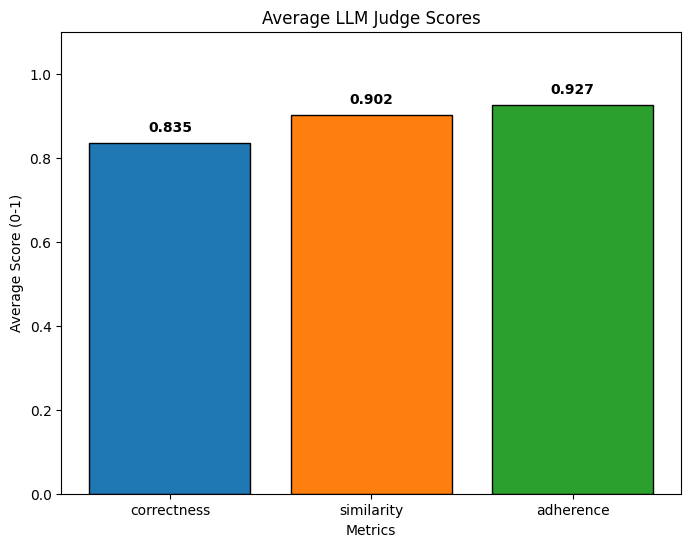

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the scored CSV
csv_path = "./RepliQA_Llamma_responses_Qwen_scores.csv"
df = pd.read_csv(csv_path)

# Calculate the mean for the 3 score columns
score_columns = ['correctness', 'similarity', 'adherence']
averages = df[score_columns].mean()

# Create the plot
plt.figure(figsize=(8, 6))
bars = plt.bar(averages.index, averages.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')

# Set y-axis limits since scores are between 0 and 1
plt.ylim(0, 1.1)  # slightly above 1 to leave room for the text labels

# Add titles and labels
plt.title('Average LLM Judge Scores')
plt.ylabel('Average Score (0-1)')
plt.xlabel('Metrics')

# Add the exact values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.show()